# Day 11 : Gradient Boosting, ROC-AUC & Bias vs Variance

In [55]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import accuracy_score, recall_score, precision_score, f1_score

df = pd.read_csv('train.csv')

## Question 1 - Baseline Setup

In [56]:
X = df[['Pclass','Age','Fare','SibSp','Parch']].copy()
y = df['Survived'].copy()

X['Median_Age'] = X.groupby('Pclass')['Age'].transform('median')
X['Age'].fillna(X['Median_Age'], inplace=True)
#print(X.isna().sum())
X.drop(columns=['Median_Age'], inplace=True)

X['FamilySize'] = X['SibSp'] + X['Parch'] +1
X['IsAlone'] = [1 if X['FamilySize'][i] == 1 else 0 for i in range(len(X))] 

X.drop(columns=['SibSp','Parch'], inplace=True)

X_train,X_test,y_train,y_test = train_test_split(X,y, test_size=0.2, random_state=42)
print(X_train.shape)
print(X_test.shape)

(712, 5)
(179, 5)


## Question 2 - Train Gradient Boosting

In [57]:
model = GradientBoostingClassifier(random_state=42)
model.fit(X_train,y_train)

,loss,'log_loss'
,learning_rate,0.1
,n_estimators,100
,subsample,1.0
,criterion,'friedman_mse'
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_depth,3
,min_impurity_decrease,0.0
,init,None


## Question 3 - Evaluate Model

In [58]:
base_pred = model.predict(X_test)
base_acc = accuracy_score(np.array(y_test), base_pred)
base_precision = precision_score(np.array(y_test), base_pred)
base_recall = recall_score(np.array(y_test), base_pred)
base_f1 = f1_score(np.array(y_test), base_pred)

evaluate_df = pd.DataFrame({
    "Metric":['Accuracy','Precision','Recall','F1'],
    "Value": [base_acc, base_precision, base_recall, base_f1]
})

evaluate_df

,Metric,Value
0,Accuracy,0.754190
1,Precision,0.840909
2,Recall,0.500000
3,F1,0.627119


## Question 4 - Compare Models

In [59]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression

log_reg = LogisticRegression()
dec_tree = DecisionTreeClassifier(random_state=42)
forest = RandomForestClassifier(random_state=42)

log_reg.fit(X_train,y_train)
dec_tree.fit(X_train,y_train)
forest.fit(X_train,y_train)

log_pred = log_reg.predict(X_test)
dec_pred = dec_tree.predict(X_test)
forest_pred = forest.predict(X_test)

y_true = np.array(y_test)
preds = [log_pred,dec_pred,forest_pred]
comparison_df = pd.DataFrame()

for idx,pred in enumerate(preds):
    models=["Logistic","Decision","Forest"]
    temp_dict = {
        "Model": models[idx],
        "Accuracy" : accuracy_score(y_true, pred),
        "Precision": precision_score(y_true, pred),
        "Recall": recall_score(y_true,pred),
        "F1": f1_score(y_true,pred)
    }
    comparison_df = pd.concat([comparison_df,pd.DataFrame([temp_dict])])

print(comparison_df)
print(evaluate_df.T)




      Model  Accuracy  Precision    Recall        F1
0  Logistic  0.770950   0.811321  0.581081  0.677165
0  Decision  0.653631   0.590909  0.527027  0.557143
0    Forest  0.759777   0.731343  0.662162  0.695035
               0          1       2         3
Metric  Accuracy  Precision  Recall        F1
Value    0.75419   0.840909     0.5  0.627119


1. Random Forest seems to be the best model with an overall average score above the rest.
2. Decision Trees are most interpretable
3. Random Forest, as all its metrics are pretty decent and I can hyperparam tune the model to make it better as well.

## Question 5 - Probability Predictions

In [ ]:
probs = model.predict_proba(X_test)
probs_df = X_test.copy()
probs_df['Prob Yes'] = probs[:,0] # This will be No
probs_df['Prob No'] = probs[:,1]  # This will ne Yes because Binary values 1 for yes, 0 or no

probs_df.iloc[:20]

,Pclass,Age,Fare,FamilySize,IsAlone,Prob Yes,Prob No
709,3,24.0,15.2458,3,0,0.602860,0.397140
439,2,31.0,10.5000,1,1,0.600802,0.399198
840,3,20.0,7.9250,1,1,0.651760,0.348240
720,2,6.0,33.0000,2,0,0.084264,0.915736
39,3,14.0,11.2417,2,0,0.519984,0.480016
290,1,26.0,78.8500,1,1,0.243871,0.756129
300,3,24.0,7.7500,1,1,0.695165,0.304835
333,3,16.0,18.0000,3,0,0.645286,0.354714
208,3,16.0,7.7500,1,1,0.638020,0.361980
136,1,19.0,26.2833,3,0,0.459016,0.540984


## Question 6 - ROC Curve

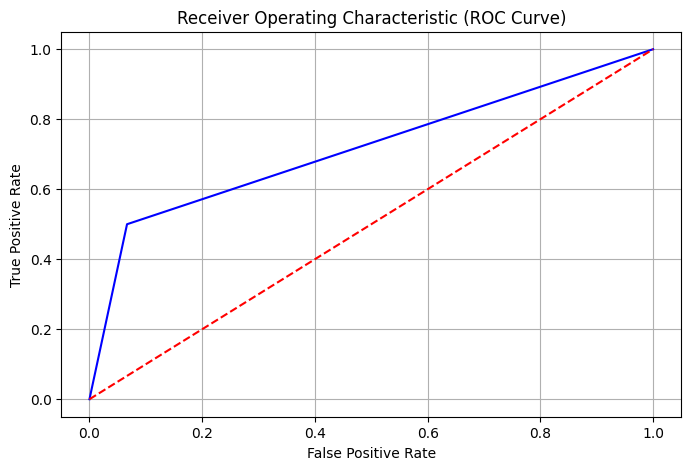

In [ ]:
# Had to google this stuff lmao had forgotten it

from sklearn.metrics import roc_curve, roc_auc_score

fpr, tpr, thresholds = roc_curve(y_true, base_pred)  # Need to use predict_proba instead of base_pred for both.
base_auc_score = roc_auc_score(y_true, base_pred)

plt.figure(figsize=(8,5))
plt.plot(fpr, tpr, color='blue', label=f"ROC Curve (AUC = {base_auc_score:.2f})")
plt.plot([0,1],[0,1], color='red', linestyle='--', label='Random Guessing')
plt.title('Receiver Operating Characteristic (ROC Curve)')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.grid(True)
plt.show()

AUC is area under the curve which shows how much of the model is predicting false positives vs true positives.

## Question 7 - Model Ranking

In [ ]:
log_auc = roc_auc_score(y_true,log_pred)
dec_auc = roc_auc_score(y_true, dec_pred)
forest_auc = roc_auc_score(y_true, forest_pred) # need to use predict_proba instead of pred values here too

auc_ranking_df = pd.DataFrame({
    'Model' : ['LogisticRegression','DecisionTreeClassifier','RandomForestClassifier','GradientBoostingClassifier'],
    'AUC' : [log_auc,dec_auc,forest_auc,base_auc_score]
})

auc_ranking_df.sort_values(by='AUC', ascending=False, inplace=True)
auc_ranking_df

,Model,AUC
2,RandomForestClassifier,0.745367
0,LogisticRegression,0.742921
3,GradientBoostingClassifier,0.716667
1,DecisionTreeClassifier,0.634942


Accuracy measures all true values over all predicted values whereas AUC measures all the True Positives vs False Positives.

## Question 8 - Bias vs Variance

**Gotta google this too cuz ive forgotten lmao**

| Model | Bias | Variance|
| ----- | ---- | ------- |
| Log Reg | High | Low |
| Dec Tree | Low | High |
| Random Forest | Low (Its Medium) | Low (Its Medium) |

Random forest has low bias and low variance because it is a cluster of multiple trees that vote together and thus reduce and variance due and bias of the normal decision tree model

## Question 9 - Overfitting Investigation

In [64]:
new_model = GradientBoostingClassifier(n_estimators=500)
new_model.fit(X_train, y_train)
train_pred = new_model.predict(X_train)
test_pred = new_model.predict(X_test)

train_acc = accuracy_score(np.array(y_train),train_pred)
test_acc = accuracy_score(np.array(y_test), test_pred)

print(f"Train Acc : {train_acc}\nTest Acc : {test_acc}")

Train Acc : 0.9199438202247191
Test Acc : 0.7206703910614525


Yes there are clear signs of overfitting, high training accuracy with comparatively low test accuracy are clear signs of overfitting.

## Question 10 - Quant Research Thinking

Model A is more interesting as although the overall accuracy is just 51%, the true positives are right 75% of the time. Since accuracy measures TP+TN/TP+FP+TN+FN, there must be more false negatives which drive the accuracy down. Thus although overall accuracy may be 51%, the model would perform way better if we were to place a trade at every positive signal.

## Bonus ML Question

1. Cross Validation helps the model test how it does on unseen data. It basically tells us whether the model is reliable in the real world or if it is overfitting or underfitting.
2. It is useful to confirm any suspicions of overfitting or underfitting in a ML model.
3. CV because it tells us if the model is overfitting or not.

---

## DSA Challenge #7

In [66]:
nums = [1,2,3,4,4,9]
target = 8
size = len(nums)
left = 0
right = size - 1

while left < right:
    temp_sum = nums[left]+nums[right]
    if temp_sum == target:
        print([nums[left],nums[right]])
        break
    elif temp_sum < target:
        left += 1
    else:
        right -= 1
  

[4, 4]


1. Sorting the array makes the logic of two pointer possible as if sum is less than target then we know that the smaller number is too small and vice versa, thus traversing the list from both ends until target is achieved.
2. O(n)
3. Reduced time complexity thus quicker computation.

## DSA Challenge #8

In [69]:
s = "abcabcbb"
substring =[]
max_len = 0

for char in s:
    if char in substring:
        print(max_len)
        break
    else:
        substring.append(char)
        max_len=len(substring)

## Correct Solution
def longest_substring(s):
    seen = set()
    left = 0
    max_len = 0

    for right in range(len(s)):
        while s[right] in seen:
            seen.remove(s[left])
            left +=1
        seen.add(s[right])

        max_len = max(max_len, right-left+1)
    
    return max_len
longest_substring(s)

3


3

1. Brute force is expensive because it will use nested loops to iterate through it twice and thus increase execution time.
2. Helps by only iterating through the list just once and decreasing execution speed.
3. O(n+k)